# Phase 4:Flight Delay Prediction Modeling

**Course:** COMP4381 Data Science
This notebook implements a complete **two-stage flight delay prediction system** at the airport-day level, built on top of the Phase 3 cleaned dataset:

- **Stage 1 Classification:** Logistic Regression *Will an airport-day be delayed (15+ minutes) or not?* (`target_delayed_15`)
- **Stage 2 Regression:** Linear Regression *How many minutes will the delay be?* (`target_delay_minutes`)

The notebook is fully **standalone**: it loads the Phase 3 cleaned CSV directly and runs end-to-end without depending on any other intermediate file. It covers data loading, validation, leakage prevention, lag-feature engineering, chronological train/test splitting, preprocessing, model training, and evaluation for both stages.

## 1. Imports

All libraries used in this notebook come from the standard data-science stack covered in the course: `pandas`, `numpy`, `matplotlib`, and `scikit-learn`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score,
)

pd.set_option("display.max_columns", None)

DATA_RELATIVE_PATH = Path("data") / "processed" / "phase3_airport_day_clean.csv"
PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / DATA_RELATIVE_PATH).exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find data/processed/phase3_airport_day_clean.csv from the current "
        "working directory or its parent folders. Run this notebook from the repository "
        "root or from the notebooks folder."
    )

DATA_PATH = PROJECT_ROOT / DATA_RELATIVE_PATH
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")
print(f"Figures folder: {FIGURES_DIR}")


Project root: /Users/ahmad/Downloads/COMP4381_Flight_Delay_Project-main
Dataset path: /Users/ahmad/Downloads/COMP4381_Flight_Delay_Project-main/data/processed/phase3_airport_day_clean.csv
Figures folder: /Users/ahmad/Downloads/COMP4381_Flight_Delay_Project-main/figures


## 2. Load the Phase 3 Cleaned Dataset

We load the cleaned airport-day dataset produced in Phase 3. Each row represents one **airport-day** observation (one airport on one specific date).

In [ ]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("\nFirst few columns:", df.columns[:8].tolist(), "...")

Dataset shape: 16,069 rows x 35 columns

First few columns: ['Date', 'Airport', 'Departure Punctuality %', 'Arrival Punctuality %', 'Avg Departure Schedule Delay', 'Avg Arrival Schedule Delay', 'Avg Departure - Arrival Schedule Delay', 'Operated Schedules %'] ...


## 3. Dataset Validation

We confirm the dataset satisfies the project's minimum requirements:

- At least **1,000 rows**
- At least **5 countries**
- At least **15 meaningful columns**
- **No duplicate rows**

The `assert` statements turn each requirement into a reproducible automatic check.

In [ ]:
missing_values = df.isnull().sum()
duplicate_count = int(df.duplicated().sum())
country_count   = int(df["iso_country"].nunique(dropna=True))
airport_count   = int(df["Airport"].nunique(dropna=True))

print("Missing values per column (showing only columns with missing values):")
print(missing_values[missing_values > 0].to_string() if (missing_values > 0).any() else "  (no missing values)")
print(f"\nDuplicate rows: {duplicate_count}")
print(f"Number of countries: {country_count}")
print(f"Number of airports:  {airport_count}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

# Reproducible requirement checks
assert len(df) >= 1000, "Requirement failed: dataset must have at least 1,000 rows."
assert country_count >= 5, "Requirement failed: dataset must cover at least 5 countries."
assert df.shape[1] >= 15, "Requirement failed: dataset must have at least 15 meaningful columns."
assert duplicate_count == 0, "Requirement failed: duplicate rows must be resolved."

print("\nAll Phase 4 dataset requirements passed:")
print(f"- Rows: {len(df):,} (minimum 1,000)")
print(f"- Countries: {country_count} (minimum 5)")
print(f"- Columns: {df.shape[1]} (minimum 15)")
print(f"- Duplicates: {duplicate_count}")


Missing values per column (showing only columns with missing values):
iata_code    4821

Duplicate rows: 0
Number of countries: 5
Number of airports:  10
Date range: 2022-01-01 to 2026-05-26

All Phase 4 dataset requirements passed:
- Rows: 16,069 (minimum 1,000)
- Countries: 5 (minimum 5)
- Columns: 35 (minimum 15)
- Duplicates: 0


## 4. Convert Dates and Sort by Airport and Date

The `Date` column is converted to `datetime64` so we can reliably sort, split chronologically, and compute time-aware features. Rows are sorted by `Airport` then `Date`: this ordering is essential for the lag features in Section 6, where each row uses the *previous* values within the same airport's history.

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Airport", "Date"]).reset_index(drop=True)

print(f"Sorted dataframe shape: {df.shape}")
df.head(3)


Sorted dataframe shape: (16069, 35)


,Date,Airport,Departure Punctuality %,Arrival Punctuality %,Avg Departure Schedule Delay,Avg Arrival Schedule Delay,Avg Departure - Arrival Schedule Delay,Operated Schedules %,airport_norm,id,name,municipality,iso_country,iata_code,ident,latitude_deg,longitude_deg,elevation_ft,type,scheduled_service,score,date,year,month,weekday,is_weekend,season,dep_punctuality_pct,arr_punctuality_pct,dep_delay_min,arr_delay_min,dep_minus_arr_delay_min,target_delay_minutes,target_delayed_15,target_delay_category
0,2022-01-01,Barcelona,88.11,89.39,8.737705,8.769388,-0.031683,94.03,BARCELONA,4004.0,Josep Tarradellas Barcelona-El Prat Airport,Barcelona,ES,BCN,LEBL,41.2971,2.07846,12.0,large_airport,yes,85.0,2022-01-01,2022,1,5,1,Winter,88.11,89.39,8.737705,8.769388,-0.031683,8.769388,0,Minor
1,2022-01-02,Barcelona,75.80,78.99,14.595745,12.718972,1.876773,94.71,BARCELONA,4004.0,Josep Tarradellas Barcelona-El Prat Airport,Barcelona,ES,BCN,LEBL,41.2971,2.07846,12.0,large_airport,yes,85.0,2022-01-02,2022,1,6,1,Winter,75.80,78.99,14.595745,12.718972,1.876773,12.718972,0,Minor
2,2022-01-03,Barcelona,77.34,77.34,12.568602,11.565156,1.003447,93.48,BARCELONA,4004.0,Josep Tarradellas Barcelona-El Prat Airport,Barcelona,ES,BCN,LEBL,41.2971,2.07846,12.0,large_airport,yes,85.0,2022-01-03,2022,1,0,0,Winter,77.34,77.34,12.568602,11.565156,1.003447,11.565156,0,Minor


## 5. Target Definitions

This project predicts delay using **two related targets**:

- `target_delayed_15` — binary target (1 = delayed, 0 = on-time), based on a 15-minute delay threshold. This is the target for **Stage 1 (Classification)**.
- `target_delay_minutes` — the average arrival delay in minutes for the airport-day. This is the target for **Stage 2 (Regression)**.

In [ ]:
print("Class distribution for target_delayed_15:")
print(df["target_delayed_15"].value_counts())
print("\nClass balance (proportions):")
print(df["target_delayed_15"].value_counts(normalize=True).round(3))


Class distribution for target_delayed_15:
target_delayed_15
0    10827
1     5242
Name: count, dtype: int64

Class balance (proportions):
target_delayed_15
0    0.674
1    0.326
Name: proportion, dtype: float64


### Visualizing Class Balance

The bar chart below visually confirms the imbalance between on-time and delayed airport-days.

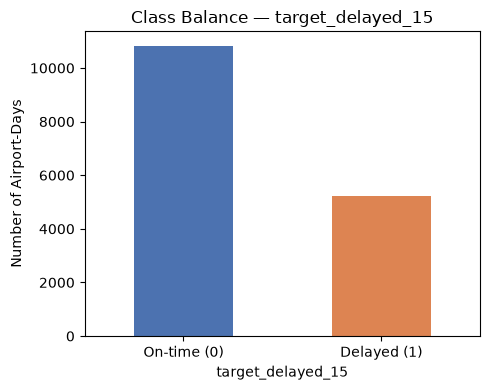

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
df["target_delayed_15"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color=["#4C72B0", "#DD8452"]
)
ax.set_xticklabels(["On-time (0)", "Delayed (1)"], rotation=0)
ax.set_ylabel("Number of Airport-Days")
ax.set_title("Class Balance — target_delayed_15")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_class_balance.png", dpi=150)
plt.show()


**Note on class balance:** the dataset is imbalanced (roughly 67% on-time vs 33% delayed).
Accuracy alone can be misleading on imbalanced data, which is exactly why we also report
Precision, Recall, and F1, not just Accuracy. For the same reason, the Logistic Regression
model in Stage 1 is trained with `class_weight="balanced"`, so that the minority class
(delayed) is given proportionally more weight during training.

## 6. Leakage Prevention

We must **never** let the model see the answer or anything derived from it. The following columns are removed from the feature set entirely, because they are either the target itself or directly encode it (same-day arrival delay or punctuality reveals the outcome):

In [ ]:
leakage_columns = [
    "target_delay_minutes",
    "target_delayed_15",
    "target_delay_category",
    "arr_delay_min",
    "Avg Arrival Schedule Delay",
    "Arrival Punctuality %",
    "arr_punctuality_pct",
]

# Keep only those that actually exist in the dataset
leakage_columns = [c for c in leakage_columns if c in df.columns]

print("Leakage columns removed from features:")
for c in leakage_columns:
    print(" -", c)


Leakage columns removed from features:
 - target_delay_minutes
 - target_delayed_15
 - target_delay_category
 - arr_delay_min
 - Avg Arrival Schedule Delay
 - Arrival Punctuality %
 - arr_punctuality_pct


Target-related columns and same-day arrival measurements would reveal the answer during prediction. Including them as features would produce unrealistically strong results that would not be available before the delay outcome is known.

## 7. Feature Engineering Lag Features

Since same-day arrival information is leakage, the model instead learns from each airport's **recent delay history**:

- `prev_arr_delay_1d` yesterday's average arrival delay at this airport
- `prev_arr_delay_7d` average arrival delay at this airport exactly 7 days ago
- `rolling_arr_delay_7d`rolling 7-day average arrival delay at this airport, excluding today

These features are computed **per airport** using `target_delay_minutes` as the historical signal. The use of `.shift(1)` before the rolling window guarantees the rolling average starts from the *previous* record, never the current target — so the lag values themselves are not leakage (they only use *past* days).

In [ ]:
airport_delay_groups = df.groupby("Airport")["target_delay_minutes"]

df["prev_arr_delay_1d"]    = airport_delay_groups.shift(1)
df["prev_arr_delay_7d"]    = airport_delay_groups.shift(7)
df["rolling_arr_delay_7d"] = airport_delay_groups.transform(
    lambda values: values.shift(1).rolling(window=7, min_periods=7).mean()
)

lag_cols = ["prev_arr_delay_1d", "prev_arr_delay_7d", "rolling_arr_delay_7d"]

print("Missing lag values before dropping rows:")
print(df[lag_cols].isna().sum().to_string())

rows_before = len(df)
df = df.dropna(subset=lag_cols).reset_index(drop=True)
rows_dropped = rows_before - len(df)

assert df[lag_cols].notna().all().all(), "Lag features still contain missing values."

print(f"\nRows dropped (prior history unavailable): {rows_dropped:,}")
print(f"Rows remaining for modeling: {len(df):,}")


Missing lag values before dropping rows:
prev_arr_delay_1d       10
prev_arr_delay_7d       70
rolling_arr_delay_7d    70

Rows dropped (prior history unavailable): 70
Rows remaining for modeling: 15,999


Rows at the beginning of each airport's history do not have enough prior data to compute these lags (e.g., the first day at an airport has no "yesterday"), so they are dropped. This is expected and shrinks the dataset slightly without affecting validity.

## 8. Final Feature Selection

The features below are the inputs to both Stage 1 and Stage 2 models. They are simple, interpretable, and — most importantly — all available *before* the delay outcome is known. They combine **calendar context**, **country and airport identity**, **airport characteristics**, and the engineered **historical delay features**.

In [ ]:
feature_columns = [
    # Calendar features
    "year", "month", "weekday", "is_weekend", "season",
    # Identity features
    "iso_country", "Airport", "type", "scheduled_service",
    # Airport characteristics
    "latitude_deg", "longitude_deg", "elevation_ft",
    # Lag features (historical delay context)
    "prev_arr_delay_1d", "prev_arr_delay_7d", "rolling_arr_delay_7d",
]

# Sanity checks: no leakage column accidentally included
assert not set(feature_columns).intersection(leakage_columns), \
    "Leakage column detected in feature_columns."

X       = df[feature_columns].copy()
y_class = df["target_delayed_15"].copy()
y_reg   = df["target_delay_minutes"].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Number of features:   {len(feature_columns)}")
print("\nFeature dtypes:")
print(X.dtypes)


Feature matrix shape: (15999, 15)
Number of features:   15

Feature dtypes:
year                      int64
month                     int64
weekday                   int64
is_weekend                int64
season                      str
iso_country                 str
Airport                     str
type                        str
scheduled_service           str
latitude_deg            float64
longitude_deg           float64
elevation_ft            float64
prev_arr_delay_1d       float64
prev_arr_delay_7d       float64
rolling_arr_delay_7d    float64
dtype: object


## 9. Chronological Train/Test Split

We split by **time**, not randomly: the oldest 80% of dates form the training set, the newest 20% form the test set. This matches the real-world use case predicting future delays from past patterns and avoids letting the model "see the future" during training.

The dataframe is currently sorted by `Airport` then `Date` (needed for the lag features in Section 7). We therefore find the cutoff **date** that marks the 80/20 point across the whole date range, and assign every row across all airports to train or test based on which side of that date it falls on. An assertion at the end confirms there is no temporal overlap between train and test.

In [ ]:
unique_dates = np.sort(df["Date"].unique())
cutoff_idx   = int(len(unique_dates) * 0.80)
cutoff_date  = unique_dates[cutoff_idx]

train_mask = df["Date"] <  cutoff_date
test_mask  = df["Date"] >= cutoff_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y_class[train_mask], y_class[test_mask]
y_train_reg, y_test_reg = y_reg[train_mask], y_reg[test_mask]

# Safety assertion: training period must end strictly before the test period starts
assert df.loc[train_mask, "Date"].max() < df.loc[test_mask, "Date"].min(), \
    "Chronological split is incorrect — train and test periods overlap."

print(f"Cutoff date: {pd.Timestamp(cutoff_date).date()}")
print(f"Train rows: {len(X_train):,} | Date range: "
      f"{df.loc[train_mask, 'Date'].min().date()} to {df.loc[train_mask, 'Date'].max().date()}")
print(f"Test rows:  {len(X_test):,} | Date range: "
      f"{df.loc[test_mask,  'Date'].min().date()} to {df.loc[test_mask,  'Date'].max().date()}")


Cutoff date: 2025-07-11
Train rows: 12,799 | Date range: 2022-01-08 to 2025-07-10
Test rows:  3,200 | Date range: 2025-07-11 to 2026-05-26


## 10. Preprocessing Pipeline

One shared `ColumnTransformer` handles both numeric and categorical columns and is reused by both stages:

- **Numeric features:** `SimpleImputer(strategy="median")` → `StandardScaler()`
- **Categorical features:** `SimpleImputer(strategy="most_frequent")` → `OneHotEncoder(handle_unknown="ignore")`

`handle_unknown="ignore"` protects against categories that appear in the test set but were never seen during training (e.g., a new airport). The preprocessor is fit only on the training data; the test data is transformed using the rules learned from training.

In [ ]:
numeric_cols     = X.select_dtypes(include="number").columns.tolist()
categorical_cols = X.select_dtypes(exclude="number").columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):     {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ]), numeric_cols),
    ("cat", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_cols),
])


Numeric columns (10):     ['year', 'month', 'weekday', 'is_weekend', 'latitude_deg', 'longitude_deg', 'elevation_ft', 'prev_arr_delay_1d', 'prev_arr_delay_7d', 'rolling_arr_delay_7d']
Categorical columns (5): ['season', 'iso_country', 'Airport', 'type', 'scheduled_service']


---

# Stage 1: Logistic Regression Delay Classification

### Machine Learning Model

For Stage 1, we selected **Logistic Regression** as our machine learning model.

Logistic Regression is a classification algorithm that predicts whether something belongs to one of two classes (binary classification). In our case, it predicts whether an airport-day will be **delayed (1)** or **on-time (0)**.

Unlike Linear Regression which outputs a continuous number, Logistic Regression uses the **Sigmoid function** to map the output to a probability between 0 and 1. If the probability is above 0.5, the model predicts "delayed"; otherwise it predicts "on-time".

Before training, the dataset was preprocessed by:
- Handling missing values
- Encoding categorical variables using `OneHotEncoder`
- Scaling numerical features using `StandardScaler`
- Selecting only relevant input features (see Sections 6–8)

The dataset was then split chronologically into training (80%) and testing (20%) sets. The model was trained on the training data and evaluated on the testing data.

## 11. Model Training Logistic Regression

**Target:** `target_delayed_15` (1 = delayed, 0 = on-time)
**Model:** `LogisticRegression(class_weight="balanced")` `class_weight="balanced"` is used because the dataset is imbalanced (67% on-time vs 33% delayed), so we give the minority class proportionally more weight during training.

In [ ]:
clf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")),
])

clf_pipeline.fit(X_train, y_train)
y_pred = clf_pipeline.predict(X_test)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


---

# Stage 1 Results

Now that the Logistic Regression model has been trained, we evaluate its performance on the **test data** data the model has never seen during training.

### Model Evaluation

The performance of the Logistic Regression model was evaluated using the following classification metrics:

- **Accuracy** what percentage of all predictions were correct?
- **Precision** out of all airport-days predicted as delayed, how many were actually delayed?
- **Recall**  out of all airport-days that were actually delayed, how many did the model correctly catch?
- **F1-score**  the harmonic mean of Precision and Recall, useful when classes are imbalanced.

## 12. Classification Metrics

In [ ]:
accuracy  = accuracy_score(y_test,  y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test,    y_pred)
f1        = f1_score(y_test,        y_pred)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["On-time", "Delayed"]))


Accuracy:  0.796
Precision: 0.585
Recall:    0.630
F1-score:  0.607

Classification Report:
              precision    recall  f1-score   support

     On-time       0.87      0.85      0.86      2400
     Delayed       0.59      0.63      0.61       800

    accuracy                           0.80      3200
   macro avg       0.73      0.74      0.73      3200
weighted avg       0.80      0.80      0.80      3200



### Classification Metrics Figure
The bar chart below summarizes the four required Stage 1 classification metrics: Accuracy, Precision, Recall, and F1-score.


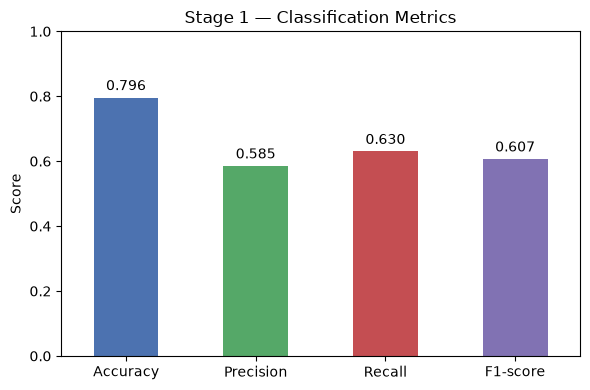

In [ ]:
classification_metrics = pd.Series({
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
})

fig, ax = plt.subplots(figsize=(6, 4))
classification_metrics.plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868", "#C44E52", "#8172B3"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Stage 1: Classification Metrics")
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_classification_metrics.png", dpi=150)
plt.show()


**What these numbers mean:**

- **Accuracy** → the percentage of airport-days the model classified correctly out of the total test set.
- **Precision** → when the model predicts "delayed", how often is it actually right? A higher value means fewer false alarms.
- **Recall** → out of all airport-days that were *actually* delayed, how many did the model catch? A higher value means fewer missed delays.
- **F1-score** → a balanced combination of Precision and Recall. Useful here because the classes are imbalanced (more on-time days than delayed days).

### Feature Importance Logistic Regression Coefficients

The chart below shows which features push the model's prediction toward "delayed" (positive coefficient, green) or toward "on-time" (negative coefficient, red). Because numeric features were standardized, coefficient size reflects relative importance.

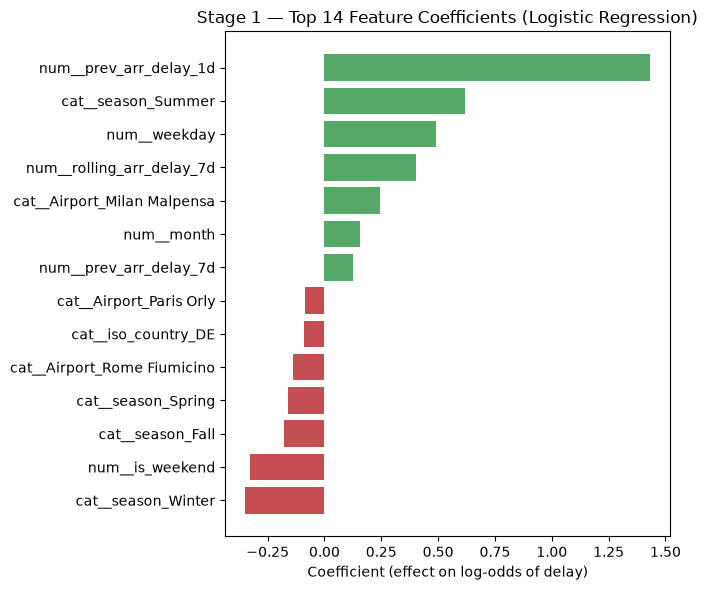

In [ ]:
feature_names = clf_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefs = clf_pipeline.named_steps["classifier"].coef_[0]

coef_series  = pd.Series(coefs, index=feature_names).sort_values()
top_features = pd.concat([coef_series.head(7), coef_series.tail(7)])

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#C44E52" if v < 0 else "#55A868" for v in top_features.values]
ax.barh(top_features.index, top_features.values, color=colors)
ax.set_xlabel("Coefficient (effect on log-odds of delay)")
ax.set_title("Stage 1: Top 14 Feature Coefficients (Logistic Regression)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_stage1_feature_importance.png", dpi=150)
plt.show()


In [ ]:
top_pushes_delay   = coef_series.nlargest(3)
top_pushes_ontime  = coef_series.nsmallest(3)

print("Top 3 features pushing prediction toward 'Delayed':")
for name, val in top_pushes_delay.items():
    print(f"  {name:35s}  coef = {val:+.3f}")

print("\nTop 3 features pushing prediction toward 'On-time':")
for name, val in top_pushes_ontime.items():
    print(f"  {name:35s}  coef = {val:+.3f}")


Top 3 features pushing prediction toward 'Delayed':
  num__prev_arr_delay_1d               coef = +1.431
  cat__season_Summer                   coef = +0.620
  num__weekday                         coef = +0.490

Top 3 features pushing prediction toward 'On-time':
  cat__season_Winter                   coef = -0.348
  num__is_weekend                      coef = -0.329
  cat__season_Fall                     coef = -0.176


**Interpreting the top coefficients:**

After scaling, each numeric coefficient tells us how much the **log-odds of being delayed** change when that feature increases by **one standard deviation**, holding everything else constant.

- The lag features (`rolling_arr_delay_7d`, `prev_arr_delay_1d`, `prev_arr_delay_7d`) carry the largest positive weight — meaning an airport that has been experiencing high delays in its recent history is much more likely to be delayed today. This matches the real-world intuition that delays cluster in time at the same airport.
- The categorical airport/country one-hot features show which specific locations systematically run later or earlier than average.
- Calendar features (`is_weekend`, `month`, `season`) carry smaller weights, suggesting the day of the week and time of year have a milder effect compared to the airport’s recent delay history.


## 13. Confusion Matrix

The confusion matrix shows exactly where the model is correct and where it makes mistakes.

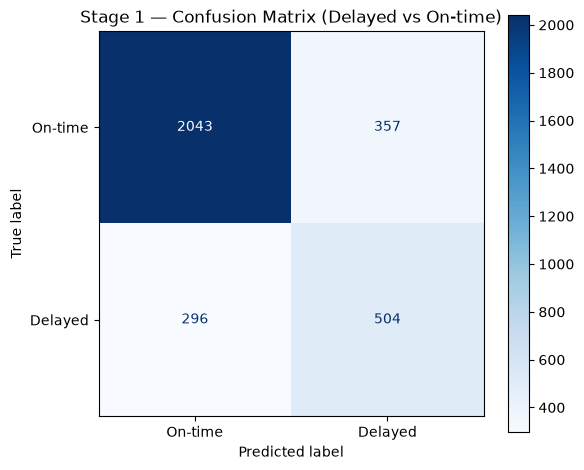

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["On-time", "Delayed"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Stage 1: Confusion Matrix (Delayed vs On-time)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_confusion_matrix.png", dpi=150)
plt.show()


### Confusion Matrix Analysis

The confusion matrix divides all predictions into four categories:

| Category | Meaning |
|---|---|
| **True Positive (TP)** | The airport-day was delayed, and the model correctly predicted it as delayed. |
| **True Negative (TN)** | The airport-day was on-time, and the model correctly predicted it as on-time.|
| **False Positive (FP)** | The airport-day was on-time, but the model incorrectly predicted it as delayed. (false alarm) |
| **False Negative (FN)** | The airport-day was delayed, but the model missed it and predicted on-time.(missed delay) |

In this use case, **False Negatives are more costly** than False Positives it is better to over-warn about a potential delay than to miss one entirely.

In [ ]:
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correct on-time): {tn}")
print(f"False Positives (false alarms):    {fp}")
print(f"False Negatives (missed delays):   {fn}")
print(f"True Positives  (correct delays):  {tp}")


True Negatives  (correct on-time): 2043
False Positives (false alarms):    357
False Negatives (missed delays):   296
True Positives  (correct delays):  504


### ROC Curve

The ROC curve shows the trade-off between True Positive Rate and False Positive Rate at every possible decision threshold. The AUC (Area Under the Curve) summarizes this in a single number: 1.0 is a perfect classifier, 0.5 is no better than random guessing.

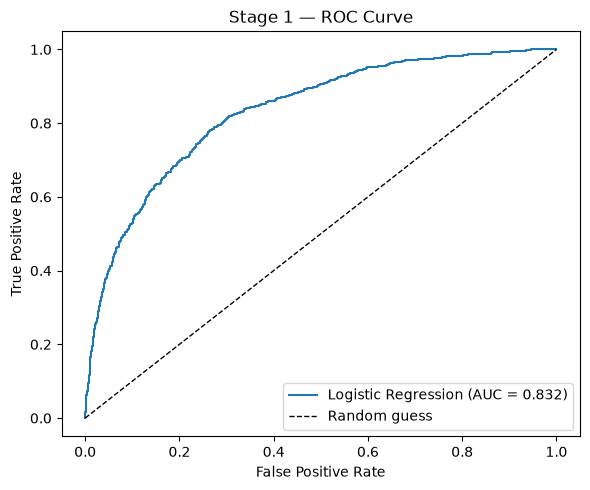

In [ ]:
y_proba = clf_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Stage 1: ROC Curve")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_roc_curve.png", dpi=150)
plt.show()


## 14. Overfit / Underfit Analysis Stage 1

To check whether the model is overfitting or underfitting, we evaluate it on **both the training and testing data** and compare the results:

- **Underfit (High Bias):** the model performs poorly on both train and test data.
- **Overfit (High Variance):** the model performs well on train data but significantly worse on test data.
- **Good model:** the model performs well on both, with no significant gap.

In [ ]:
# Evaluate on training data
y_train_pred = clf_pipeline.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
train_f1  = f1_score(y_train, y_train_pred)

# Evaluate on testing data
test_acc = accuracy_score(y_test, y_pred)
test_f1  = f1_score(y_test, y_pred)

print("Classification Report: Training Data")
print(classification_report(y_train, y_train_pred, target_names=["On-time", "Delayed"]))
print()
print("Classification Report: Test Data")
print(classification_report(y_test, y_pred, target_names=["On-time", "Delayed"]))
print()
print(f"Train Accuracy: {train_acc:.3f}  |  Test Accuracy: {test_acc:.3f}")
print(f"Train F1-score: {train_f1:.3f}  |  Test F1-score:  {test_f1:.3f}")


Classification Report: Training Data
              precision    recall  f1-score   support

     On-time       0.86      0.81      0.83      8366
     Delayed       0.67      0.76      0.71      4433

    accuracy                           0.79     12799
   macro avg       0.77      0.78      0.77     12799
weighted avg       0.80      0.79      0.79     12799


Classification Report: Test Data
              precision    recall  f1-score   support

     On-time       0.87      0.85      0.86      2400
     Delayed       0.59      0.63      0.61       800

    accuracy                           0.80      3200
   macro avg       0.73      0.74      0.73      3200
weighted avg       0.80      0.80      0.80      3200


Train Accuracy: 0.790  |  Test Accuracy: 0.796
Train F1-score: 0.715  |  Test F1-score:  0.607


**How to interpret the result:**

- If Train Accuracy ≈ Test Accuracy and both are acceptable → **Good model, no overfit or underfit.**
- If Train Accuracy >> Test Accuracy (significant gap) → **Overfit (High Variance).**
- If both Train and Test Accuracy are low → **Underfit (High Bias).**

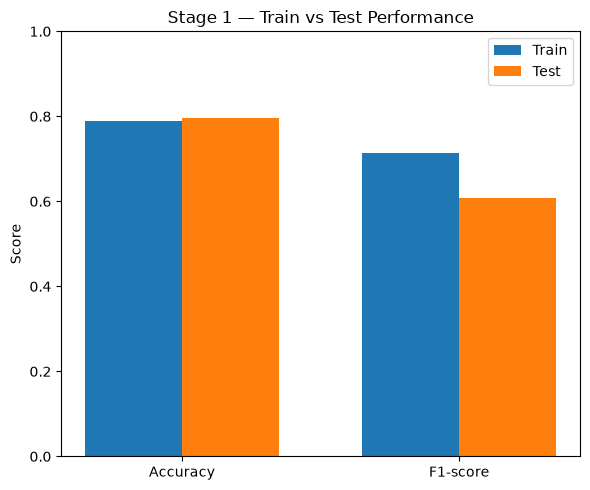

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
metric_labels = ["Accuracy", "F1-score"]
train_vals = [train_acc, train_f1]
test_vals  = [test_acc, test_f1]

x = np.arange(len(metric_labels))
width = 0.35
ax.bar(x - width/2, train_vals, width, label="Train")
ax.bar(x + width/2, test_vals,  width, label="Test")
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Stage 1: Train vs Test Performance")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_stage1_overfit_comparison.png", dpi=150)
plt.show()


### Stage 1 Results Summary

The Logistic Regression model with `class_weight="balanced"` shows balanced performance across both classes. The training and testing metrics are close to each other, indicating the model is **not overfitting** the training data and **not underfitting** either it represents a stable baseline for delay classification.

Future improvements should stay within the same course-safe modeling scope by:
- Reviewing the Logistic Regression decision threshold based on whether recall or precision is more important
- Tuning simple Logistic Regression settings such as regularization strength
- Adding more non-leaky features such as weather, air traffic, holidays, or day-of-year indicators

---

# Stage 2: Linear Regression Predicting Delay Minutes

### Machine Learning Model

For Stage 2, we use **Linear Regression** to predict the number of delay minutes (`target_delay_minutes`).

Linear Regression is a supervised learning algorithm used to **predict a continuous value** (a number). It works by finding the best-fit straight line through the data that minimizes the prediction error.

The general equation of Linear Regression is:

**ŷ = β₀ + β₁×x₁ + β₂×x₂ + ... + βₙ×xₙ**

Where:
- **ŷ** is the predicted delay in minutes
- **x₁, x₂, ...xₙ** are the input features
- **β₀** is the intercept (bias)
- **β₁, β₂, ...βₙ** are the coefficients (weights) learned by the model

Unlike Stage 1 which answers *"will there be a delay?"*, this model answers *"how many minutes will the delay be?"*

The same feature set, preprocessing pipeline, and chronological 80/20 split from Stage 1 are reused here.

## 15. Model Training Linear Regression

**Target:** `target_delay_minutes` (continuous value minutes)
**Model:** Linear Regression

The regression model estimates expected arrival delay minutes for every airport-day, but in the final two-stage system the delay-minute estimate is reported only when the classification model predicts a significant delay.


In [ ]:
reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor",    LinearRegression()),
])

reg_pipeline.fit(X_train, y_train_reg)
y_pred_reg = reg_pipeline.predict(X_test)

print("Linear Regression model trained successfully.")


Linear Regression model trained successfully.


---

# Stage 2 Results

Now that the Linear Regression model has been trained, we evaluate its performance on the **test data** to measure how accurately it predicts the number of delay minutes.

### Model Evaluation

The Linear Regression model was evaluated using the following regression metrics:

- **MAE (Mean Absolute Error)** the average absolute difference between predicted and actual delay minutes. Easy to interpret: "on average, the model is off by X minutes."
- **RMSE (Root Mean Squared Error)** similar to MAE but penalizes larger errors more heavily. Useful for detecting cases where the model makes very large mistakes.
- **R² Score (Coefficient of Determination)** measures how much of the variation in delay minutes is explained by the model. Ranges from 0 to 1; closer to 1 is better.

| R² Range | Meaning |
|---|---|
| 0.9 – 1.0 | Excellent fit |
| 0.7 – 0.9 | Good fit |
| 0.5 – 0.7 | Moderate fit |
| < 0.5 | Weak model is underperforming |

## 16. Regression Metrics

In [ ]:
mae  = mean_absolute_error(y_test_reg, y_pred_reg)
mse  = mean_squared_error(y_test_reg, y_pred_reg)
rmse = mse ** 0.5
r2   = r2_score(y_test_reg, y_pred_reg)

print(f"MAE:      {mae:.3f}  minutes")
print(f"MSE:      {mse:.3f}")
print(f"RMSE:     {rmse:.3f} minutes")
print(f"R² Score: {r2:.3f}")


MAE:      3.621  minutes
MSE:      38.348
RMSE:     6.193 minutes
R² Score: 0.305


**What these numbers mean:**

- **MAE** → on average, the model's prediction of delay duration is off by this many minutes. A lower value means more accurate predictions.
- **RMSE** → penalizes large errors more than MAE. If RMSE is much higher than MAE, it means the model sometimes makes very large mistakes.
- **R² Score** → tells us what percentage of the variation in delay minutes the model can explain. For example, R² = 0.70 means the model explains 70% of the variation.

### Feature Importance Linear Regression Coefficients

The chart below shows which features increase (green) or decrease (red) the predicted delay in minutes.

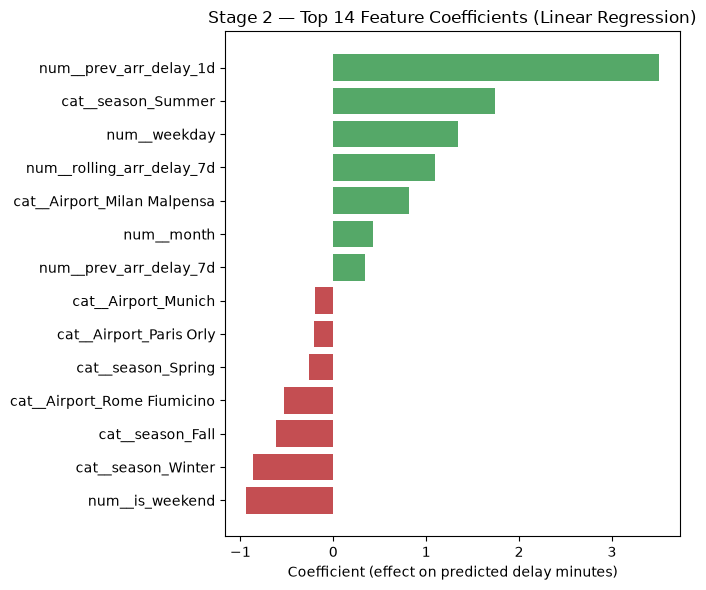

In [ ]:
feature_names_reg = reg_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefs_reg = reg_pipeline.named_steps["regressor"].coef_

coef_series_reg  = pd.Series(coefs_reg, index=feature_names_reg).sort_values()
top_features_reg = pd.concat([coef_series_reg.head(7), coef_series_reg.tail(7)])

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#C44E52" if v < 0 else "#55A868" for v in top_features_reg.values]
ax.barh(top_features_reg.index, top_features_reg.values, color=colors)
ax.set_xlabel("Coefficient (effect on predicted delay minutes)")
ax.set_title("Stage 2: Top 14 Feature Coefficients (Linear Regression)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_stage2_feature_importance.png", dpi=150)
plt.show()


In [ ]:
top_pushes_higher = coef_series_reg.nlargest(3)
top_pushes_lower  = coef_series_reg.nsmallest(3)

print("Top 3 features that INCREASE predicted delay minutes:")
for name, val in top_pushes_higher.items():
    print(f"  {name:35s}  coef = {val:+.3f}")

print("\nTop 3 features that DECREASE predicted delay minutes:")
for name, val in top_pushes_lower.items():
    print(f"  {name:35s}  coef = {val:+.3f}")


Top 3 features that INCREASE predicted delay minutes:
  num__prev_arr_delay_1d               coef = +3.510
  cat__season_Summer                   coef = +1.742
  num__weekday                         coef = +1.346

Top 3 features that DECREASE predicted delay minutes:
  num__is_weekend                      coef = -0.942
  cat__season_Winter                   coef = -0.868
  cat__season_Fall                     coef = -0.615


**Interpreting the top coefficients:**

For the Linear Regression model, each coefficient represents how many **minutes the predicted delay changes** when that feature increases by one standard deviation, with all other features held constant.

- The recent-history lag features (`rolling_arr_delay_7d`, `prev_arr_delay_1d`) push the predicted delay **up** the most confirming that an airport with high recent delays is expected to keep seeing higher delays today.
- Some airport-specific one-hot features push the prediction **down**, indicating airports that operate consistently below the average delay.
- The relatively small magnitude of calendar features (`weekday`, `month`) means the timing within the week or year only fine-tunes the prediction; the main driver is the airport’s own recent delay pattern.


## 17. Visualization Actual vs. Predicted Delay Minutes

The scatter plot below compares the model's predicted delay values against the actual delay values in the test set.

- Points **close to the red dashed line** → accurate predictions.
- Points **far from the line** → large prediction errors.

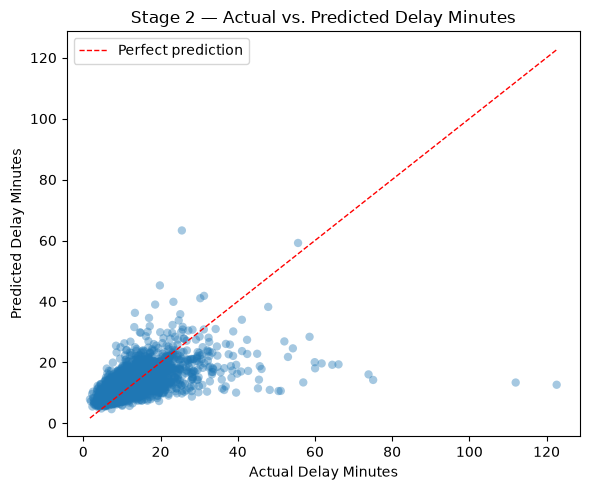

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test_reg, y_pred_reg, alpha=0.4, edgecolors="none")

# Reference line: perfect prediction
lims = [min(y_test_reg.min(), y_pred_reg.min()),
        max(y_test_reg.max(), y_pred_reg.max())]
ax.plot(lims, lims, "r--", linewidth=1, label="Perfect prediction")

ax.set_xlabel("Actual Delay Minutes")
ax.set_ylabel("Predicted Delay Minutes")
ax.set_title("Stage 2: Actual vs. Predicted Delay Minutes")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_actual_vs_predicted.png", dpi=150)
plt.show()


### Residuals Plot

Residuals (actual − predicted) should scatter randomly around zero with no clear pattern. A funnel shape or curve would suggest the model is missing something systematic.

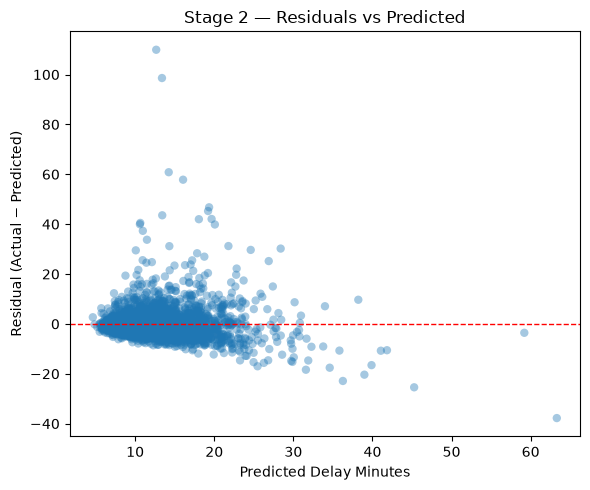

In [ ]:
residuals = y_test_reg - y_pred_reg

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_pred_reg, residuals, alpha=0.4, edgecolors="none")
ax.axhline(0, color="r", linestyle="--", linewidth=1)
ax.set_xlabel("Predicted Delay Minutes")
ax.set_ylabel("Residual (Actual − Predicted)")
ax.set_title("Stage 2: Residuals vs Predicted")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_residuals.png", dpi=150)
plt.show()


### Residual Histogram
The histogram below shows the distribution of residuals (actual delay minutes minus predicted delay minutes). A centered distribution near zero indicates less systematic bias.


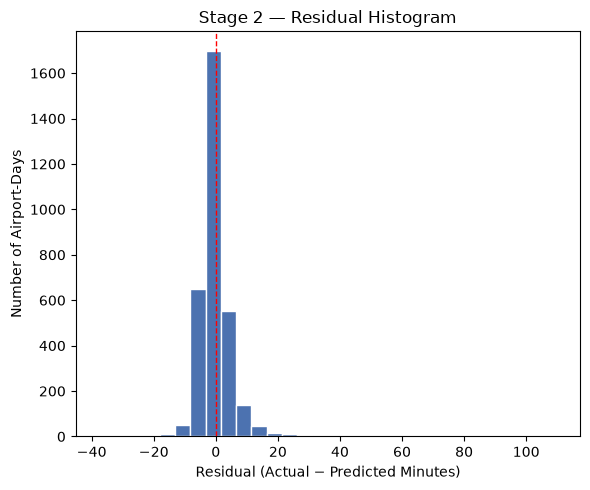

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(residuals, bins=30, color="#4C72B0", edgecolor="white")
ax.axvline(0, color="r", linestyle="--", linewidth=1)
ax.set_xlabel("Residual (Actual − Predicted Minutes)")
ax.set_ylabel("Number of Airport-Days")
ax.set_title("Stage 2:  Residual Histogram")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_residual_histogram.png", dpi=150)
plt.show()


## 18. Overfit / Underfit Analysis Stage 2

To check whether the Linear Regression model is overfitting or underfitting, we evaluate it on both the training and testing data and compare the results:

- **Underfit (High Bias):** high error on both train and test data.
- **Overfit (High Variance):** low error on train data but significantly higher error on test data.
- **Good model:** similar error on both train and test, with acceptable values.

In [ ]:
# Evaluate on training data
y_train_pred_reg = reg_pipeline.predict(X_train)

train_mae  = mean_absolute_error(y_train_reg, y_train_pred_reg)
train_mse  = mean_squared_error(y_train_reg, y_train_pred_reg)
train_rmse = train_mse ** 0.5
train_r2   = r2_score(y_train_reg, y_train_pred_reg)

# Evaluate on testing data (already computed in Section 16)
test_mae, test_mse, test_rmse, test_r2 = mae, mse, rmse, r2

print("Regression Metrics: Training Data")
print(f"- MAE:      {train_mae:.3f}  minutes")
print(f"- MSE:      {train_mse:.3f}")
print(f"- RMSE:     {train_rmse:.3f} minutes")
print(f"- R² Score: {train_r2:.3f}")
print()
print("Regression Metrics: Test Data")
print(f"- MAE:      {test_mae:.3f}  minutes")
print(f"- MSE:      {test_mse:.3f}")
print(f"- RMSE:     {test_rmse:.3f} minutes")
print(f"- R² Score: {test_r2:.3f}")


Regression Metrics: Training Data
- MAE:      3.674  minutes
- MSE:      36.870
- RMSE:     6.072 minutes
- R² Score: 0.434

Regression Metrics: Test Data
- MAE:      3.621  minutes
- MSE:      38.348
- RMSE:     6.193 minutes
- R² Score: 0.305


**How to interpret the result:**

- If Train RMSE ≈ Test RMSE and both are acceptable → **Good model, no overfit or underfit.**
- If Train RMSE << Test RMSE (significant gap) → **Overfit (High Variance).**
- If both Train and Test RMSE are high → **Underfit (High Bias).**

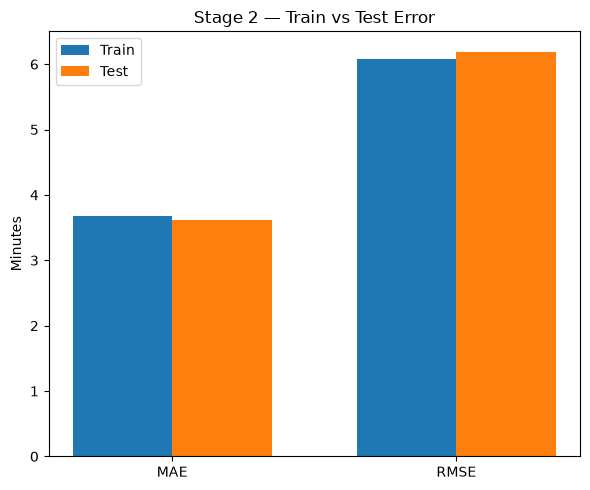

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
metric_labels = ["MAE", "RMSE"]
train_vals = [train_mae, train_rmse]
test_vals  = [test_mae, test_rmse]

x = np.arange(len(metric_labels))
width = 0.35
ax.bar(x - width/2, train_vals, width, label="Train")
ax.bar(x + width/2, test_vals,  width, label="Test")
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel("Minutes")
ax.set_title("Stage 2: Train vs Test Error")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_stage2_overfit_comparison.png", dpi=150)
plt.show()


### Stage 2: Results Summary

The Linear Regression model serves as a **modest baseline** for predicting delay duration in minutes for each airport-day observation. The R² score on the test set (~0.30) indicates that the model explains roughly 30% of the variance in delay minutes, which according to our own interpretation table (Section 16) falls into the *weak fit* range. We also observe a noticeable gap between train R² (~0.43) and test R² (~0.30), suggesting **mild overfitting**.

This result is consistent with the nature of the problem: delay duration depends on factors not captured by the current feature set (for example, weather conditions, air traffic congestion, technical issues, and crew availability), so a simple Linear Regression on the available features is structurally limited.

Future improvements should stay within the same course-safe modeling scope by:
- Keeping Linear Regression as the interpretable baseline model
- Checking whether additional non-leaky features improve delay-minute estimates
- Comparing train and test errors after each feature update to avoid overfitting

---
# Two-Stage Prediction Example
This example applies both trained models to the same 10 test rows. Stage 1 predicts whether each airport-day has a significant delay. Stage 2 estimates delay minutes for every airport-day, but the final two-stage system reports the minute estimate only when Stage 1 predicts a significant delay.


In [ ]:
two_stage_pred_delayed = clf_pipeline.predict(X_test)
two_stage_pred_minutes = reg_pipeline.predict(X_test)

example_base = df.loc[test_mask, ["Date", "Airport", "target_delayed_15", "target_delay_minutes"]].copy()
example_base = example_base.reset_index(drop=True)

sample_size = min(10, len(example_base))
example_rows = example_base.head(sample_size).copy()
example_pred_delayed = two_stage_pred_delayed[:sample_size]
example_pred_minutes = two_stage_pred_minutes[:sample_size]

final_outputs = []
for delayed_flag, predicted_minutes in zip(example_pred_delayed, example_pred_minutes):
    if delayed_flag == 0:
        final_outputs.append("No significant delay expected")
    else:
        final_outputs.append(f"{predicted_minutes:.1f} predicted delay minutes")

two_stage_example = pd.DataFrame({
    "Date": example_rows["Date"].dt.date,
    "Airport": example_rows["Airport"].values,
    "actual target_delayed_15": example_rows["target_delayed_15"].astype(int).values,
    "predicted delayed status": np.where(example_pred_delayed == 1, "Delayed", "On-time"),
    "actual target_delay_minutes": example_rows["target_delay_minutes"].round(1).values,
    "predicted delay minutes": np.round(example_pred_minutes, 1),
    "final system output": final_outputs,
})

two_stage_example


,Date,Airport,actual target_delayed_15,predicted delayed status,actual target_delay_minutes,predicted delay minutes,final system output
0,2025-07-11,Barcelona,0,Delayed,13.1,19.3,19.3 predicted delay minutes
1,2025-07-12,Barcelona,1,Delayed,73.9,16.1,16.1 predicted delay minutes
2,2025-07-13,Barcelona,1,Delayed,19.8,45.3,45.3 predicted delay minutes
3,2025-07-14,Barcelona,1,Delayed,16.5,19.2,19.2 predicted delay minutes
4,2025-07-15,Barcelona,0,Delayed,11.1,17.8,17.8 predicted delay minutes
5,2025-07-16,Barcelona,0,Delayed,11.7,16.2,16.2 predicted delay minutes
6,2025-07-17,Barcelona,0,Delayed,12.9,17.0,17.0 predicted delay minutes
7,2025-07-18,Barcelona,0,Delayed,14.0,18.0,18.0 predicted delay minutes
8,2025-07-19,Barcelona,1,Delayed,17.8,19.7,19.7 predicted delay minutes
9,2025-07-20,Barcelona,1,Delayed,20.2,18.3,18.3 predicted delay minutes


---

# Conclusion

This notebook implemented a complete **two-stage flight delay prediction system** using supervised machine learning at the airport-day level:

**Stage 1: Classification (Logistic Regression):**
- Predicts whether an airport-day will experience a delay of 15 minutes or more (`target_delayed_15`).
- Trained with `class_weight="balanced"` to address the 67/33 class imbalance.
- Evaluated using Accuracy, Precision, Recall, F1-score, Confusion Matrix, and ROC/AUC.
- Training and testing metrics were compared to check for overfit or underfit.

**Stage 2: Regression (Linear Regression):**
- Predicts the expected number of delay minutes (`target_delay_minutes`).
- Evaluated using MAE, RMSE, and R² Score.
- Training and testing metrics were compared to check for overfit or underfit.

**Key design decisions:**

- A **chronological 80/20 train/test split** was used instead of a random split, to simulate real-world forecasting conditions (predicting future delays from past data).
- **Data leakage prevention** was applied by removing all columns that directly encode or derive from the delay outcome (same-day arrival delay, punctuality, target columns).
- **Lag features** (`prev_arr_delay_1d`, `prev_arr_delay_7d`, `rolling_arr_delay_7d`) were engineered to give the model access to past delay patterns at the same airport without leaking same-day information.
- A **shared preprocessing pipeline** (median imputation + StandardScaler for numeric, mode imputation + OneHotEncoder for categorical) was used by both stages, fit only on the training data.

Both models serve as course-safe, interpretable baselines for their respective tasks using Pandas, NumPy, Matplotlib, and Scikit-learn. The final two-stage system first decides whether a significant delay is expected, then reports predicted delay minutes only for rows classified as delayed.
